In [1]:
import os
import mudata as mu
import pertpy as pt
import scanpy as sc
import pandas as pd
import mudata as mu
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

milo = pt.tl.Milo()

from pertpy.tools import Milo


In [2]:
adata_age_nk= sc.read_h5ad("/scratch/user/s4575250/BIOX7014_Thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_nk_combined_annot_with_age_scvi.h5ad")

In [3]:
adata_age_nk

AnnData object with n_obs × n_vars = 187173 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in 

In [4]:
adata_age_nk.obs['pica_cell_type_complete_01_gdT_corrected'].unique()
adata_age_nk.obs['pica_cell_type_complete_01_gdT_corrected'].value_counts()

pica_cell_type_complete_01_gdT_corrected
CD56_dim CD16+ NK           171221
CD56_dim CD16+ KLRC2+ NK     15081
CD56_bright CD16- NK           871
Name: count, dtype: int64

In [5]:
adata_age_nk.obs["pica_id"].unique()
adata_age_nk.obs["pica_id"].value_counts()

pica_id
PICA0133    5673
PICA0011    4768
PICA0086    3061
PICA0020    3040
PICA0015    2846
            ... 
PICA0040     453
PICA0003     431
PICA0139     416
PICA0142     264
PICA0119     254
Name: count, Length: 128, dtype: int64

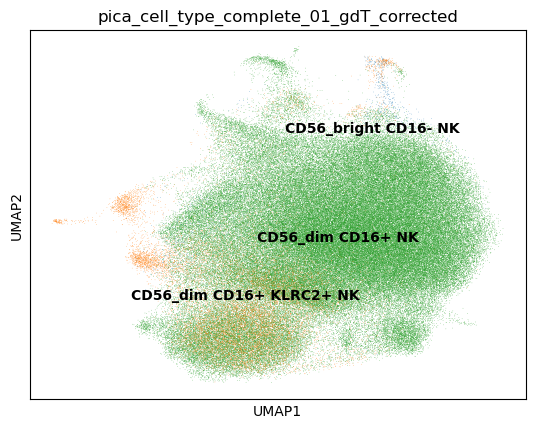

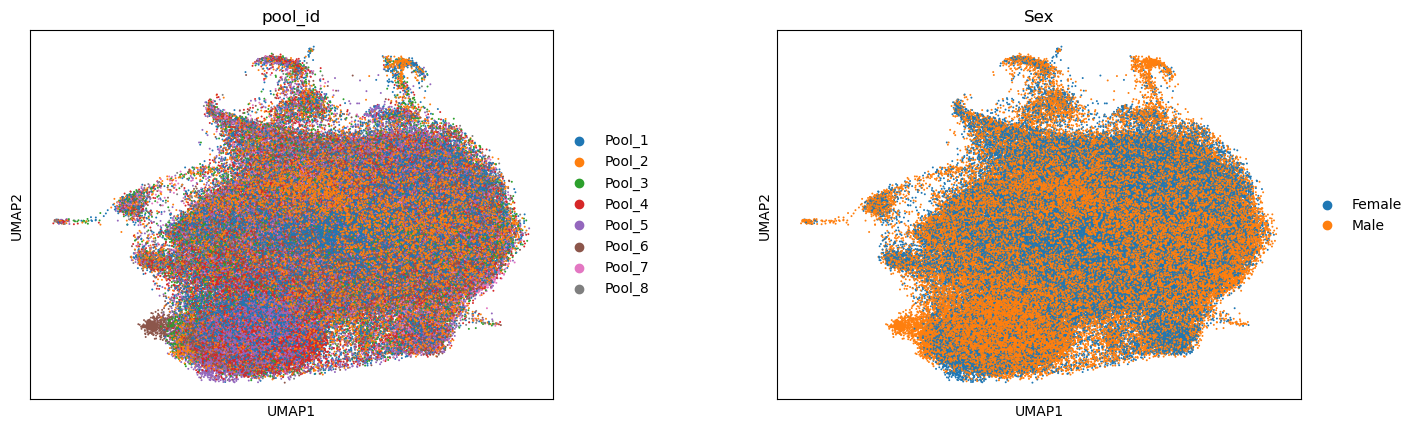

In [6]:
sc.pl.umap(adata_age_nk, color=["pica_cell_type_complete_01_gdT_corrected"], legend_loc="on data")
sc.pl.umap(adata_age_nk, color=["pool_id", "Sex"], wspace=0.3, size=8)

### Prepare for Milo analysis

In [7]:
adata_age_nk.obs["Batch"] = adata_age_nk.obs["Batch"].astype("category")
adata_age_nk.obs["Age_years"] = adata_age_nk.obs["Age_years"].astype("float")
adata_age_nk.obs["Sex"] = adata_age_nk.obs["Sex"].astype("category")
adata_age_nk.obs["Age"] = adata_age_nk.obs["Age"].astype("int")

In [8]:
adata_age_nk.obs["Sex"].value_counts()


Sex
Male      117183
Female     69990
Name: count, dtype: int64

In [9]:
adata_age_nk.obs["Age_years"].value_counts().sort_index()

Age_years
0.05     2137
0.07      969
0.14      662
0.35      709
0.48      789
         ... 
16.16    1193
16.20    1168
16.29     536
16.78    1238
17.03    1329
Name: count, Length: 122, dtype: int64

In [10]:
adata_age_nk.obs["Age_group"].value_counts().sort_index()

Age_group
0–3      38395
4–6      47808
7–10     33857
11–14    50273
15–18    16840
Name: count, dtype: int64

In [11]:
adata_age_nk.obs["Age"].value_counts().sort_index()

Age
0     11205
1      5852
2      8798
3     12540
4     19388
5     14781
6     13639
7     13179
8     10308
9      6894
10     3476
11    13299
12     7505
13    12040
14    17429
15    10180
16     5331
17     1329
Name: count, dtype: int64

In [12]:
adata_age_nk.obs.drop_duplicates(subset="pica_id").groupby(["Age_years", "Sex"]).size().reset_index(name="n_donors")

/scratch/temp/22542103/ipykernel_699943/867392425.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_age_nk.obs.drop_duplicates(subset="pica_id").groupby(["Age_years", "Sex"]).size().reset_index(name="n_donors")


,Age_years,Sex,n_donors
0,0.05,Female,0
1,0.05,Male,1
2,0.07,Female,1
3,0.07,Male,0
4,0.14,Female,0
...,...,...,...
239,16.29,Male,1
240,16.78,Female,0
241,16.78,Male,1
242,17.03,Female,1


In [13]:
adata_age_nk.obs.drop_duplicates(subset="pica_id").groupby(["Age", "Sex"]).size().reset_index(name="n_donors")

/scratch/temp/22542103/ipykernel_699943/359878167.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_age_nk.obs.drop_duplicates(subset="pica_id").groupby(["Age", "Sex"]).size().reset_index(name="n_donors")


,Age,Sex,n_donors
0,0,Female,3
1,0,Male,7
2,1,Female,1
3,1,Male,4
4,2,Female,1
5,2,Male,7
6,3,Female,6
7,3,Male,2
8,4,Female,6
9,4,Male,6


In [14]:
milo = pt.tl.Milo()
mdata_nk = milo.load(adata_age_nk)

In [15]:
mdata_nk

MuData object with n_obs × n_vars = 187173 × 38606
  2 modalities
    rna:	187173 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Batch', 'Age_group', '_scvi_batch', '_scvi_labels'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'Batch_colors', '_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'pica_cell_type_complete_01_gdT_corrected_colors', 'umap', 'pool_id_colors', 'Sex_colors'
      obsm:	'X_scVI', 'X_umap'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	0 x 0

In [16]:
# Build KNN graph
sc.pp.neighbors(mdata_nk["rna"], use_rep="X_scVI", n_neighbors=75)

In [17]:
# Build neighbourhood graph
milo.make_nhoods(mdata_nk["rna"], prop=0.1)

In [18]:
mdata_nk["rna"].obsm["nhoods"]

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 2619640 stored elements and shape (187173, 9851)>

In [19]:
mdata_nk["rna"][mdata_nk["rna"].obs["nhood_ixs_refined"] != 0].obs[["nhood_ixs_refined", "nhood_kth_distance"]]

,nhood_ixs_refined,nhood_kth_distance
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACGCGAGCACTCAA,1,3.457598
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAAGCGAGTATCCTGC,1,3.667299
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAAGGAACAAAACGAT,1,3.363439
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AACAGCCTCGCATGGT,1,3.538970
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAGGCACCACATGAAG,1,3.390574
...,...,...
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTTCAGTCAATGCGCC,1,3.708672
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTTGCCACACTCGGGT,1,4.008997
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTTGCCACAGCACACC,1,3.595360
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTTGCGTAGGTCTATG,1,4.445430


Text(0, 0.5, '# nhoods')

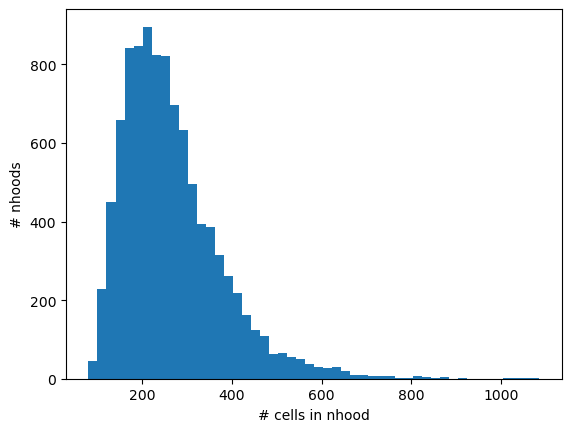

In [20]:
nhood_size = np.array(mdata_nk["rna"].obsm["nhoods"].sum(0)).ravel()
plt.hist(nhood_size, bins=50)
plt.xlabel("# cells in nhood")
plt.ylabel("# nhoods")

Text(0, 0.5, '# nhoods')

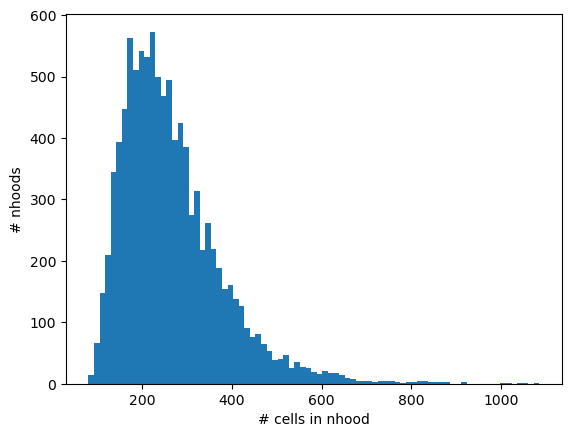

In [21]:
nhood_size = np.array(mdata_nk["rna"].obsm["nhoods"].sum(0)).ravel()
plt.hist(nhood_size, bins='auto')
plt.xlabel("# cells in nhood")
plt.ylabel("# nhoods")

In [22]:
# count cells in neighbourhood
mdata_nk= milo.count_nhoods(mdata_nk, sample_col="pica_id") 

In [23]:
mdata_nk

MuData object with n_obs × n_vars = 187173 × 38606
  2 modalities
    rna:	187173 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Batch', 'Age_group', '_scvi_batch', '_scvi_labels', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'Batch_colors', '_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'pica_cell_type_complete_01_gdT_corrected_colors', 'umap', 'pool_id_colors', 'Sex_colors', 'nhood_neighbors_key'
      obsm:	'X_scVI', 'X_umap', 'nhoods'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	128 x 9851
      var:	'index_cell', 'kth_distance'
      uns:	'sample_col'

In [24]:
mdata_nk["milo"]

AnnData object with n_obs × n_vars = 128 × 9851
    var: 'index_cell', 'kth_distance'
    uns: 'sample_col'

In [25]:
donor_meta_nk = (
    adata_age_nk.obs[["pica_id", "Age_years","Age", "Sex", "Batch", "Age_group"]]
    .drop_duplicates("pica_id")
    .set_index("pica_id")
)
donor_meta_nk = donor_meta_nk.loc[mdata_nk["milo"].obs_names]

In [26]:
mdata_nk["milo"].obs["Age_years"] = donor_meta_nk["Age_years"].values
mdata_nk["milo"].obs["Sex"] = donor_meta_nk["Sex"].values
mdata_nk["milo"].obs["Batch"] = donor_meta_nk["Batch"].values
mdata_nk["milo"].obs["Age"] = donor_meta_nk["Age"].values
mdata_nk["milo"].obs["Age_group"] = donor_meta_nk["Age_group"].values


In [27]:
mdata_nk["milo"].obs["Sex"] = mdata_nk["milo"].obs["Sex"].astype("category")
mdata_nk["milo"].obs["Age_years"] = mdata_nk["milo"].obs["Age_years"].astype("float")
mdata_nk["milo"].obs["Batch"] = mdata_nk["milo"].obs["Batch"].astype("category")
mdata_nk["milo"].obs["Age"] = mdata_nk["milo"].obs["Age"].astype("int")
mdata_nk["milo"].obs["Age_group"] = mdata_nk["milo"].obs["Age_group"].astype("category")


In [28]:
donor_meta_nk

,Age_years,Age,Sex,Batch,Age_group
PICA0001,2.09,2,Male,Batch01,0–3
PICA0002,15.09,15,Male,Batch01,15–18
PICA0003,0.83,0,Male,Batch01,0–3
PICA0004,1.46,1,Male,Batch01,0–3
PICA0005,9.30,9,Male,Batch01,7–10
...,...,...,...,...,...
PICA0164,2.15,2,Male,Batch07,0–3
PICA0166,0.62,0,Male,Batch07,0–3
PICA0168,16.20,16,Male,Batch07,15–18
PICA0169,2.72,2,Male,Batch07,0–3


In [29]:
mdata_nk["milo"]

AnnData object with n_obs × n_vars = 128 × 9851
    obs: 'Age_years', 'Sex', 'Batch', 'Age', 'Age_group'
    var: 'index_cell', 'kth_distance'
    uns: 'sample_col'

In [30]:
mdata_nk.write_h5mu(
    "/scratch/user/s4575250/BIOX7014_Thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_nk_milo_nhoods_built.h5mu"
)

In [31]:
mdata_nk["milo"].obs["Age_years"].value_counts().sort_index()

Age_years
0.05     1
0.07     1
0.14     1
0.35     1
0.48     1
        ..
16.16    1
16.20    1
16.29    1
16.78    1
17.03    1
Name: count, Length: 122, dtype: int64

In [32]:
mdata_nk["milo"].obs["Sex"].value_counts().sort_index()

Sex
Female    53
Male      75
Name: count, dtype: int64

In [33]:
mdata_nk["milo"].obs["Age_group"].value_counts().sort_index()

Age_group
0–3      31
4–6      29
7–10     21
11–14    34
15–18    13
Name: count, dtype: int64

In [34]:
mdata_nk["milo"]

AnnData object with n_obs × n_vars = 128 × 9851
    obs: 'Age_years', 'Sex', 'Batch', 'Age', 'Age_group'
    var: 'index_cell', 'kth_distance'
    uns: 'sample_col'

In [35]:
mdata_nk

MuData object with n_obs × n_vars = 187301 × 48457
  2 modalities
    rna:	187173 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Batch', 'Age_group', '_scvi_batch', '_scvi_labels', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'Batch_colors', '_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'pica_cell_type_complete_01_gdT_corrected_colors', 'umap', 'pool_id_colors', 'Sex_colors', 'nhood_neighbors_key'
      obsm:	'X_scVI', 'X_umap', 'nhoods'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	128 x 9851
      obs:	'Age_years', 'Sex', 'Batch', 'Age', 'Age_group'
      var:	'index_cell', 'kth_di